1)Linear regression by using Deep Neural network: Implement Boston housing price
prediction problem by Linear regression using Deep Neural network. Use Boston House
price prediction dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline 
plt.rcParams['figure.figsize'] = (10,5)
plt.rcParams['figure.dpi']=250


In [2]:
df = pd.read_csv("HousingData.csv")
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [3]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [7]:
for col in df.columns:
    if df[col].dtype !='object':
        df[col].fillna(df[col].median(),inplace =True)
    else:
        df[col].fillna(df[col].mode()[0],inplace=True)

<Axes: >

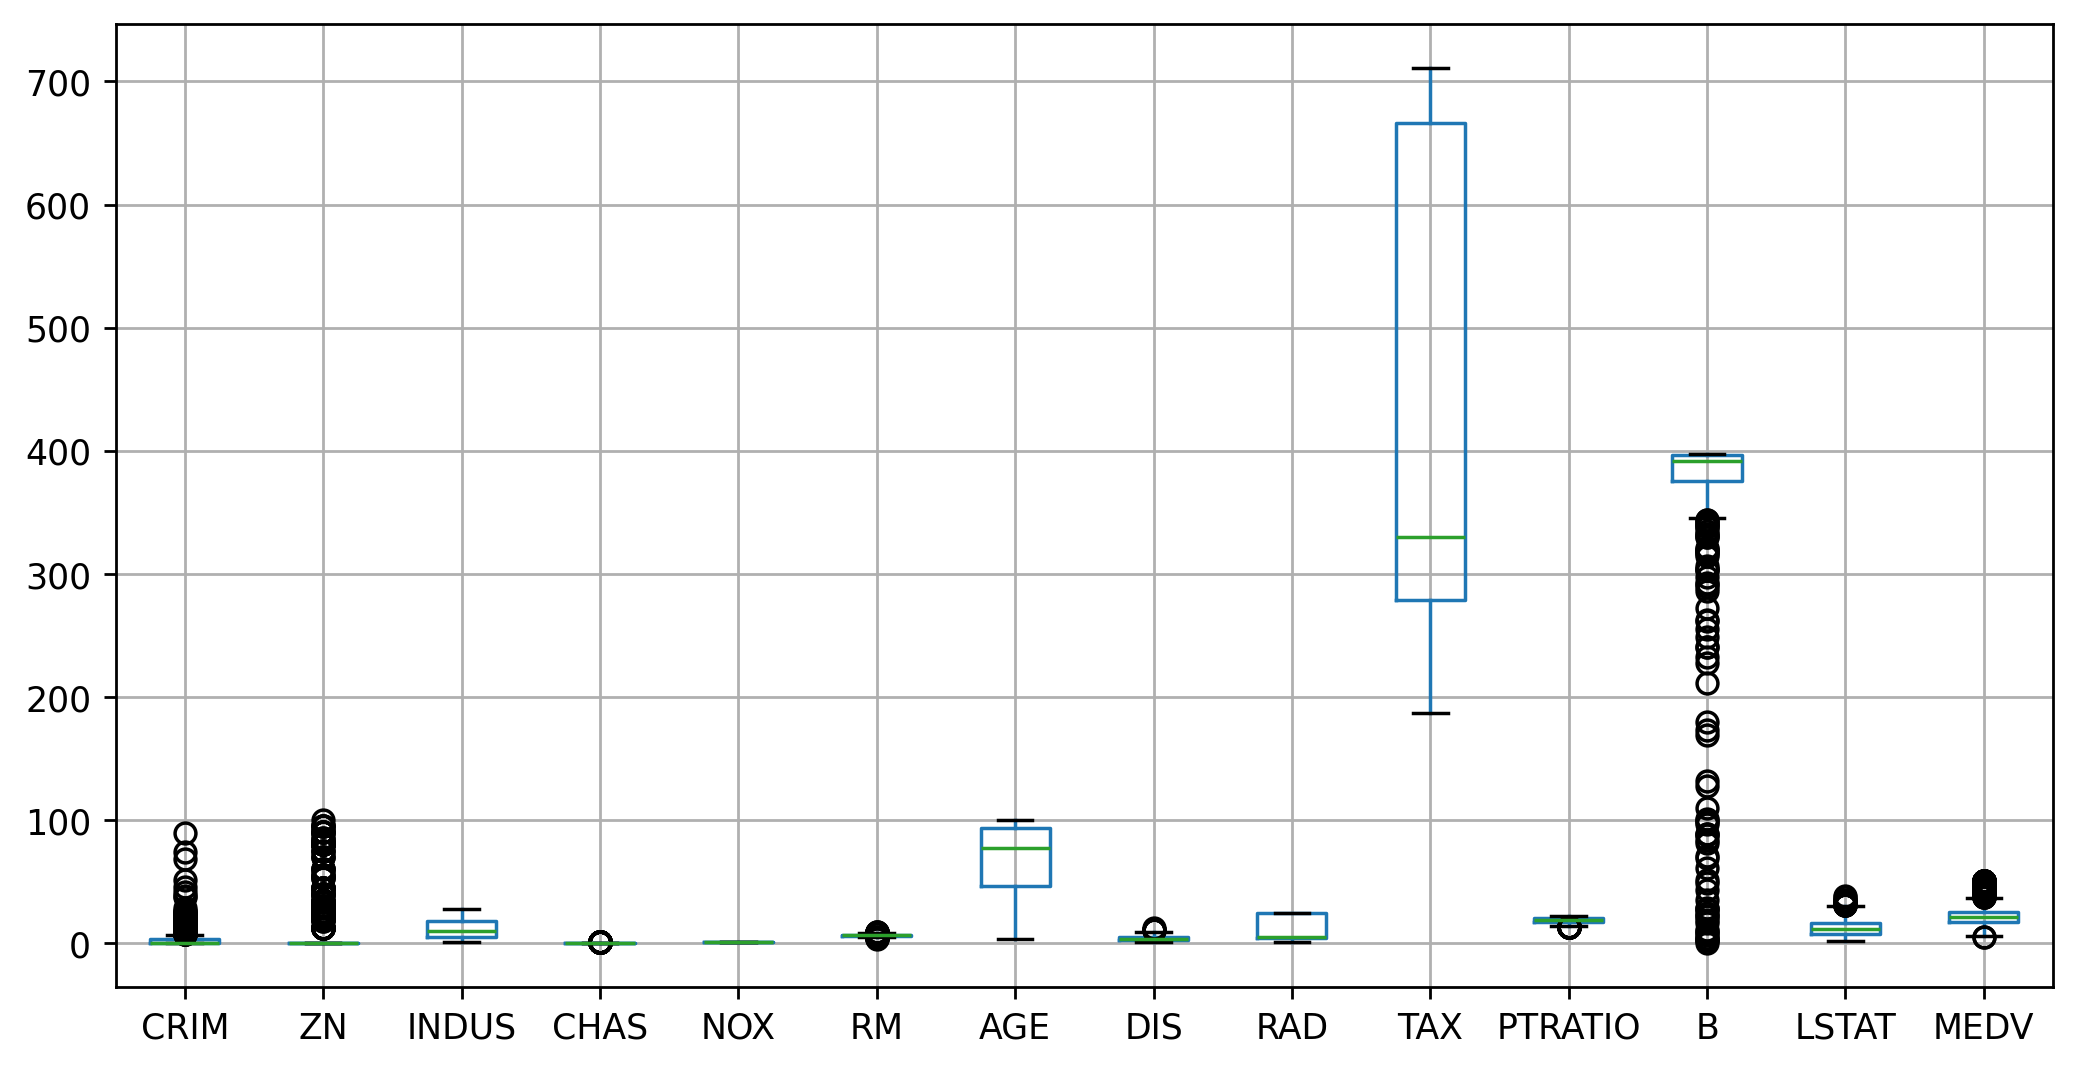

In [8]:
df.boxplot()

In [9]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [10]:
def capping(df,columns):
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1
        lower = q1-1.5*iqr
        upper = q3 +1.5*iqr
        df[col]=np.where(df[col]>upper,upper,np.where(df[col]<lower,lower,df[col]))

In [11]:
capping(df,['CRIM', 'ZN', 'INDUS',  'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'])

<Axes: >

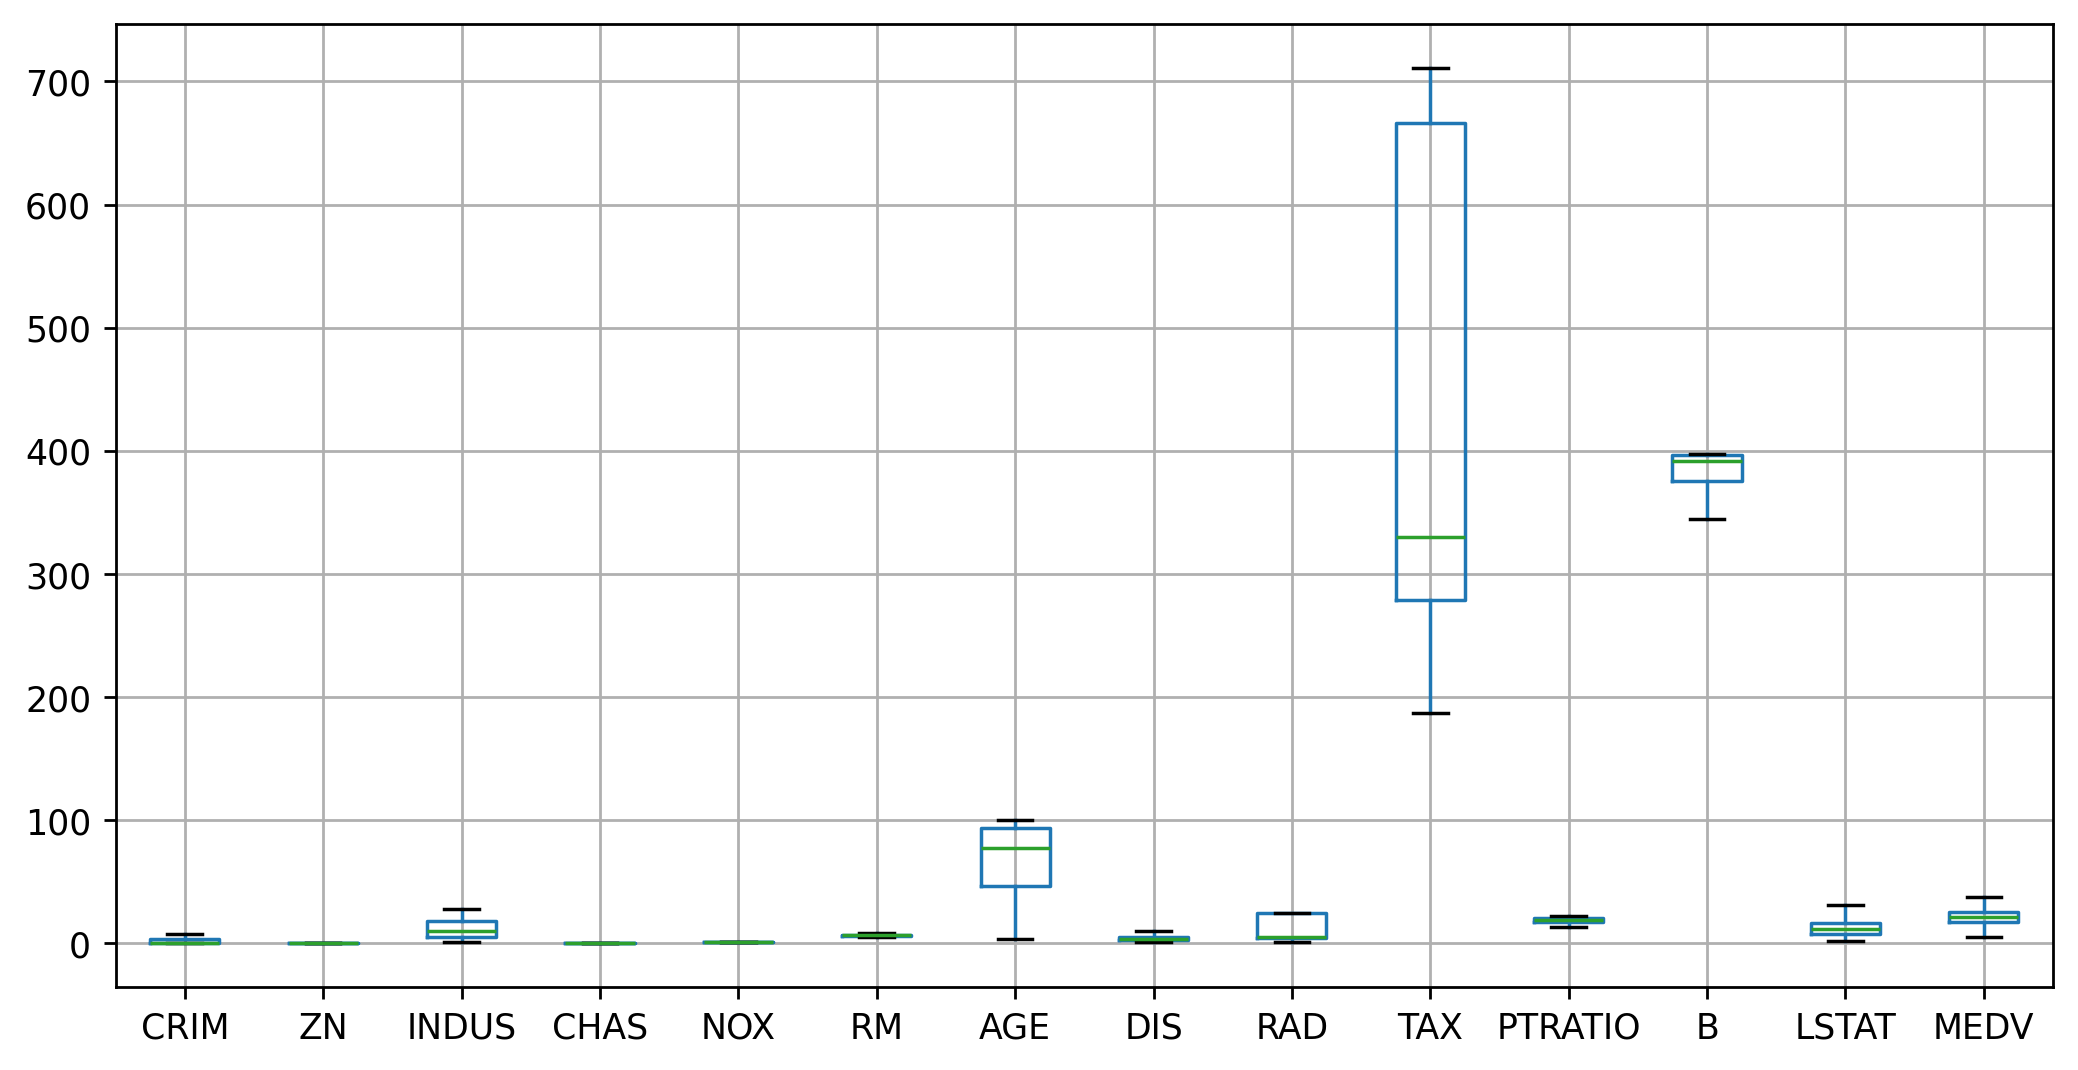

In [12]:
df.boxplot()

<Axes: xlabel='MEDV', ylabel='Count'>

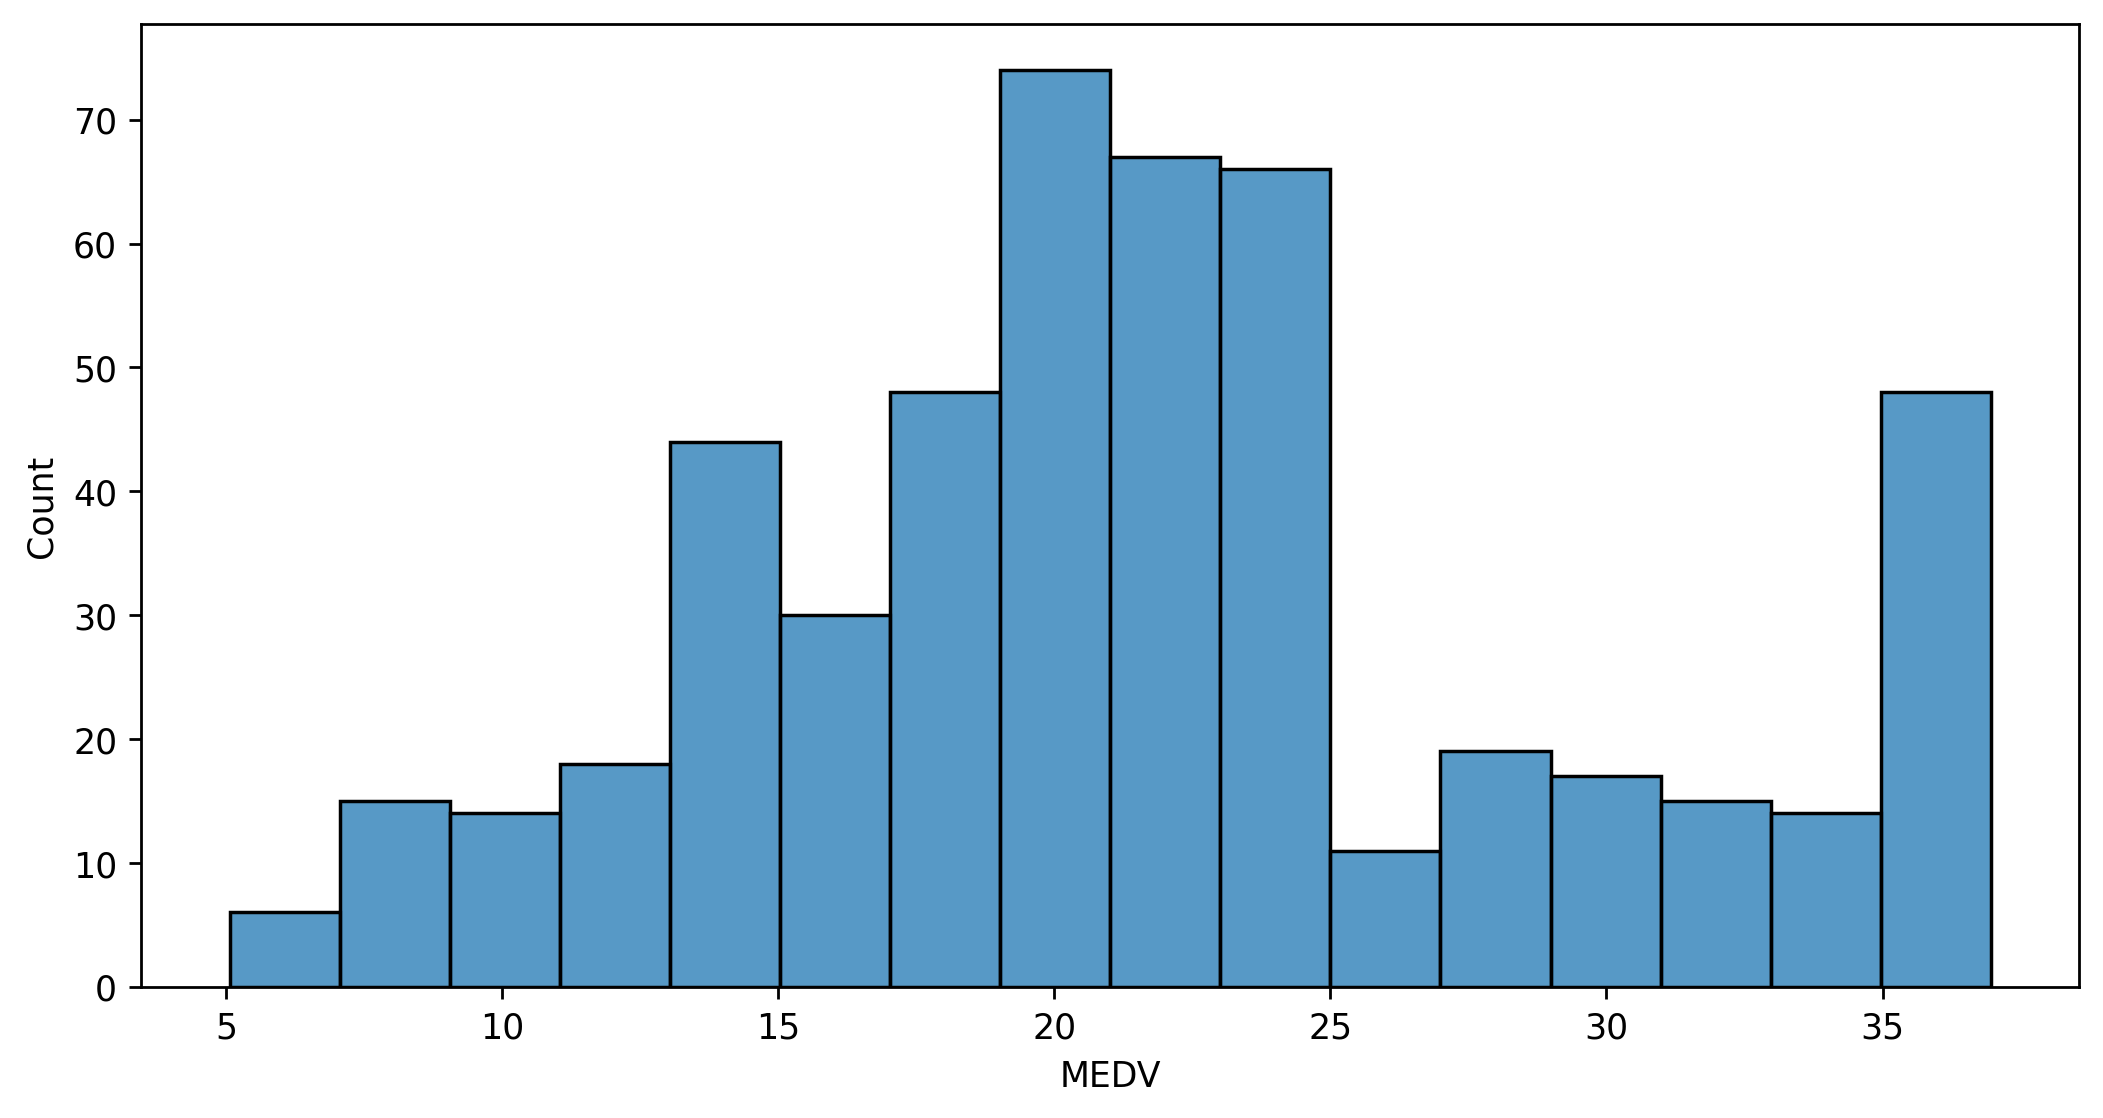

In [13]:
sns.histplot(df['MEDV'])

In [14]:
x= df.iloc[:,:-1]
y = df['MEDV']

In [15]:
sc = StandardScaler()
x = sc.fit_transform(x)

In [16]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state = 89)

In [17]:
model = Sequential()
model.add(Dense(32,activation='relu',input_dim = x.shape[1]))
model.add(Dropout(0.2))
model.add(Dense(16,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1,activation='linear'))

In [18]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics =['mean_absolute_error'])

In [19]:
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [20]:
history = model.fit(xtrain, ytrain,epochs=50,validation_data=(xtest, ytest),verbose = 1, callbacks=[early_stop])

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 530.8439 - mean_absolute_error: 21.5819 - val_loss: 482.5672 - val_mean_absolute_error: 20.5478
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 511.6535 - mean_absolute_error: 21.0601 - val_loss: 464.7309 - val_mean_absolute_error: 20.0628
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 505.9182 - mean_absolute_error: 20.9000 - val_loss: 444.2332 - val_mean_absolute_error: 19.4890
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 461.6396 - mean_absolute_error: 19.9210 - val_loss: 419.3230 - val_mean_absolute_error: 18.7893
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 451.2599 - mean_absolute_error: 19.5570 - val_loss: 387.5517 - val_mean_absolute_error: 17.9047
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 403.1356 - mean_absolute_error: 18.3793 - val_loss: 346.9923 - val_mean_absolute_error: 16.7887
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 386.5037 - 

In [21]:
train_loss = model.evaluate(xtrain,ytrain)
test_loss = model.evaluate(xtest,ytest)
ypred = model.predict(xtest)
ypred_train = model.predict(xtrain)
print(f"Training Accuracy : {r2_score(ytrain,ypred_train)}")
print(f"Testing Accuracy : {r2_score(ytest,ypred)}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 14.7561 - mean_absolute_error: 2.8431
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 14.6801 - mean_absolute_error: 2.9887
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Training Accuracy : 0.7683137562248538
Testing Accuracy : 0.7104968386176203


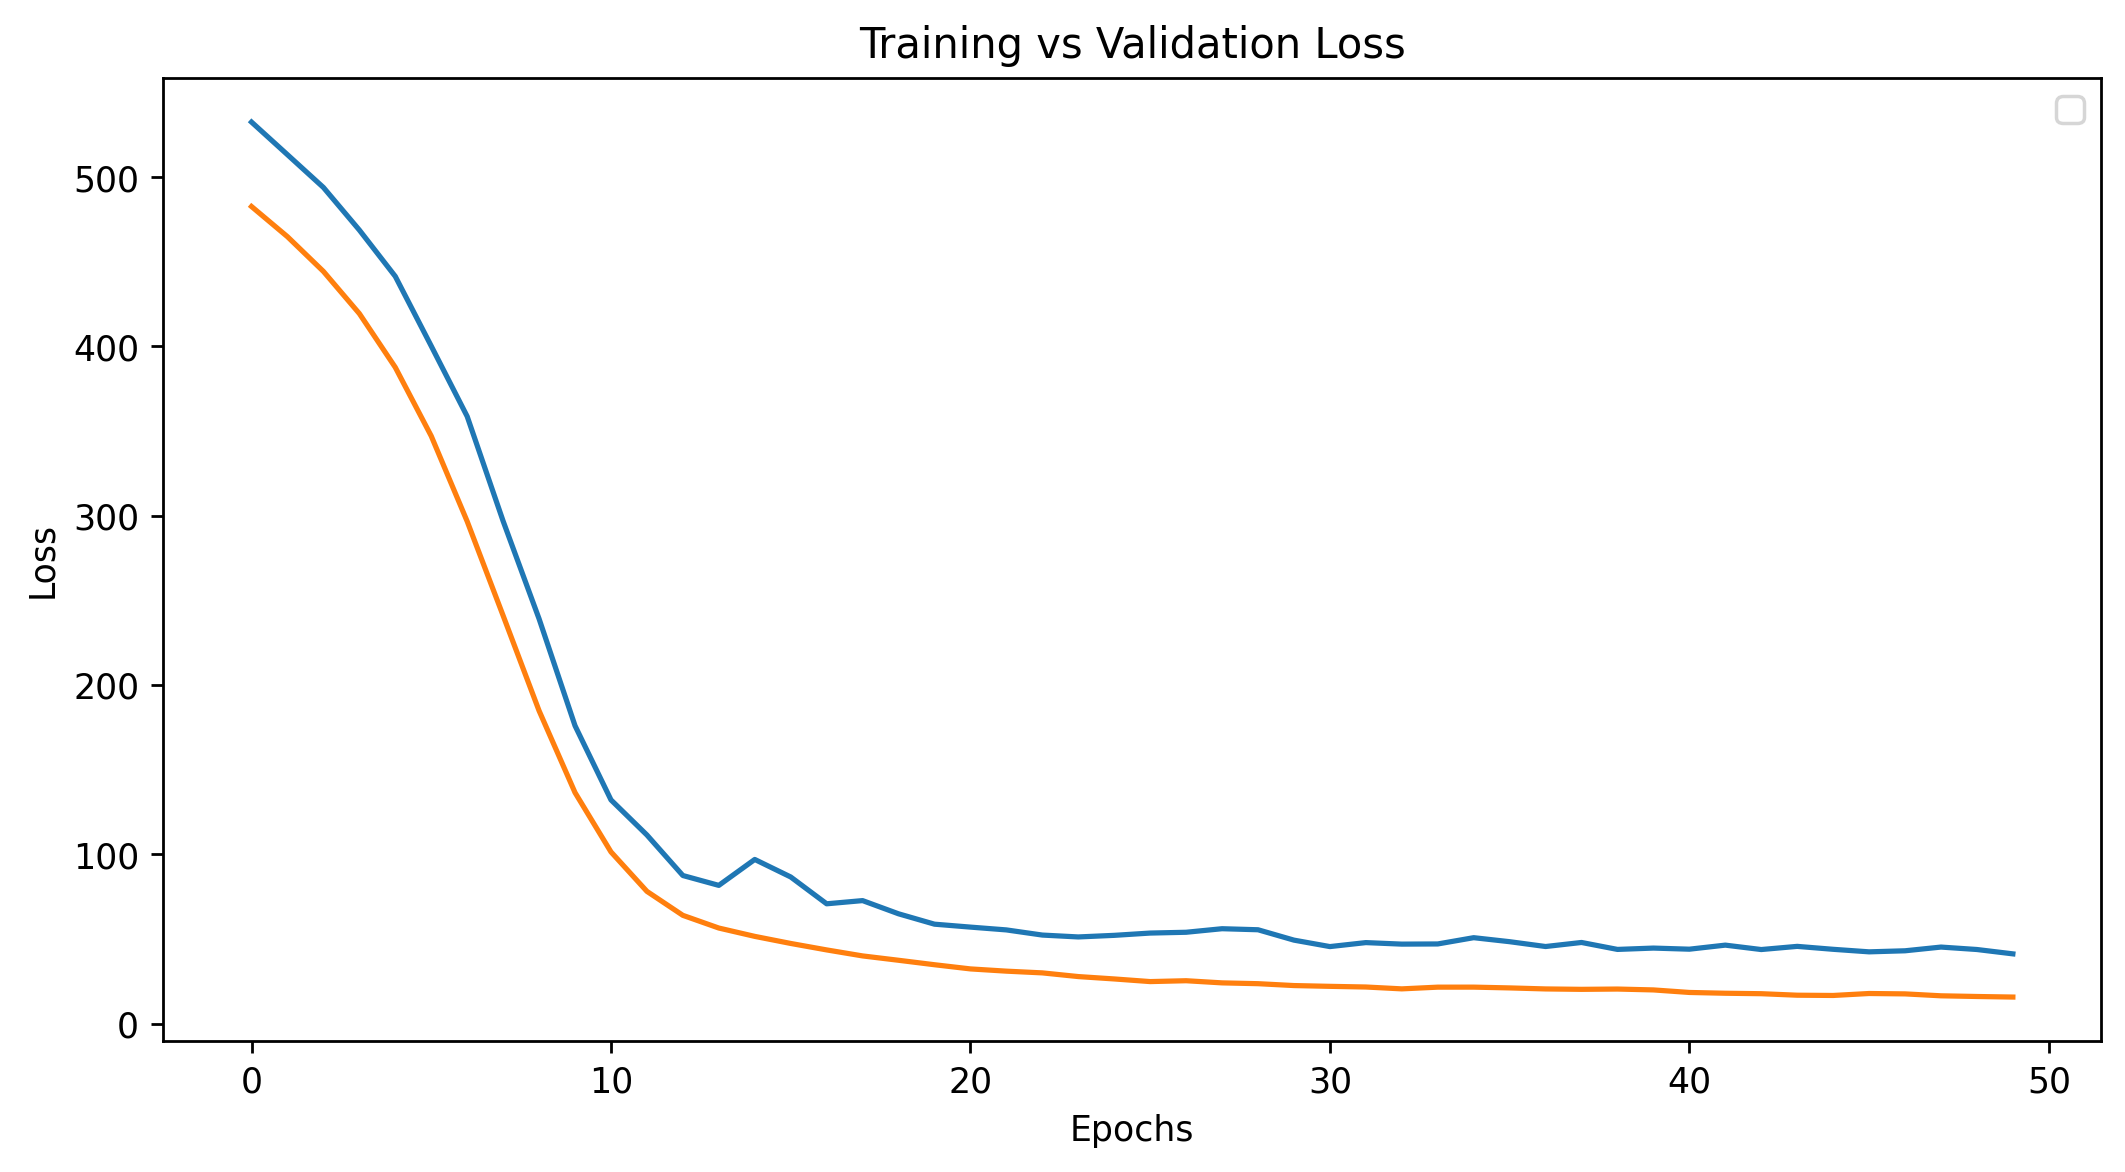

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()
# plt.xlim()

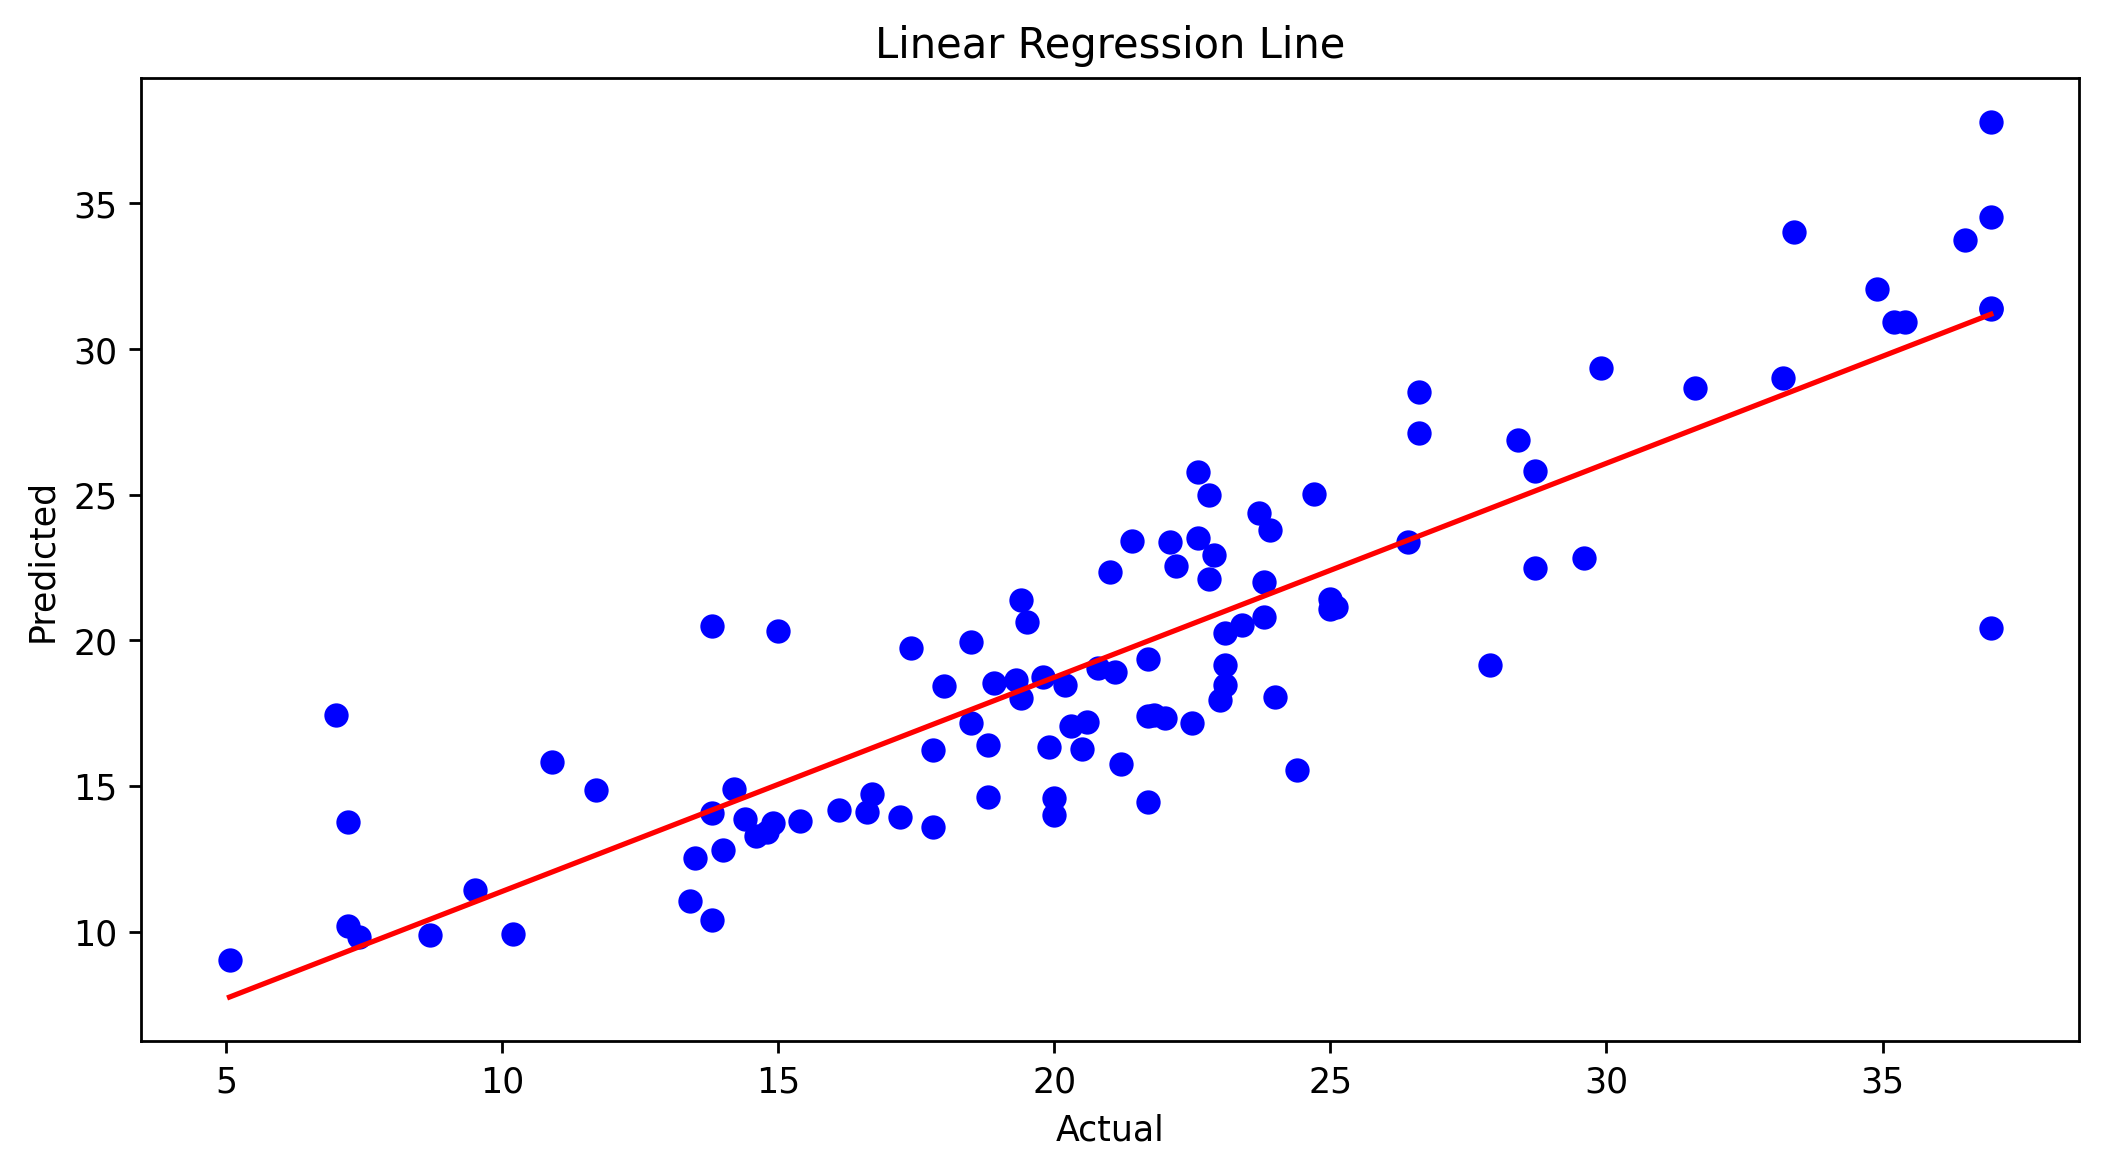

In [25]:
ypred = ypred.flatten()

# Scatter (actual data)
plt.scatter(ytest, ypred, color='blue')

# Line (y = mx + c)
m, c = np.polyfit(ytest, ypred, 1)
x_line = np.linspace(min(ytest), max(ytest), 100)
y_line = m * x_line + c

plt.plot(x_line, y_line, color='red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Line")
plt.show()